# LASSO Variable Selection for EUR/USD Log Returns

This notebook evaluates whether the macroeconomic and LLM-derived geopolitical variables contain robust linear predictive information for daily EUR/USD log returns.

The candidate predictor set contains the macroeconomic controls together with all geopolitical representations considered in the VAR-X analysis:

- daily SUM geopolitical indices,
- daily MAX geopolitical indices,
- 3-day moving averages of the daily SUM indices,
- 5-day moving averages of the daily SUM indices,
- 10-day moving averages of the daily SUM indices.

LASSO regularisation is estimated using time-series cross-validation. The analysis is subsequently complemented by contemporaneous correlation analysis and Granger causality tests to examine whether weak contemporaneous relationships may coexist with lagged predictive relationships.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

In [48]:
from pathlib import Path

data_path = Path("../../data/processed")
print(data_path.resolve())

C:\Users\franc\OneDrive\Geop-Model\data\processed


In [49]:
sorted([p.name for p in data_path.iterdir()])

['DEXUSEU_logreturns.csv',
 'DGS2_diff.csv',
 'LLM_annotations_max700_6examples.csv',
 'USEPUINDXD_diff.csv',
 'VIXCLS_levels.csv',
 'cleaned_tweets.csv',
 'fed_annotations.csv',
 'geopolitical_indices_daily_max.csv',
 'geopolitical_indices_daily_sum.csv',
 'geopolitical_indices_daily_sum_ma10.csv',
 'geopolitical_indices_daily_sum_ma3.csv',
 'geopolitical_indices_daily_sum_ma5.csv',
 'lasso_cv_selected_coefficients.csv',
 'lasso_exploratory_path_variables.csv',
 'lasso_master_dataset.csv',
 'lasso_model_summary.csv',
 'macro_baseline_common_sample.csv',
 'macro_geopolitical_ma10.csv',
 'macro_geopolitical_ma3.csv',
 'macro_geopolitical_ma5.csv',
 'macro_geopolitical_max.csv',
 'macro_geopolitical_sum.csv',
 'macro_processed.csv',
 'sanctions_annotations.csv',
 'trade_annotations.csv',
 'truths_cleaned.csv',
 'tweets_cleaned_merged_master.xlsx',
 'tweets_human_annotations.csv']

## 1. Construction of the Candidate Predictor Dataset

The macroeconomic variables and alternative geopolitical-index representations are loaded from the previously constructed modelling datasets.

Each geopolitical specification covers the same common sample. The SUM, MAX, MA3, MA5 and MA10 versions are merged by observation date so that LASSO can select among competing geopolitical representations within a single predictor set.

The resulting dataset contains 993 observations spanning 10 January 2017 to 8 January 2021.

In [50]:
sum_df = pd.read_csv(data_path / "macro_geopolitical_sum.csv")
max_df = pd.read_csv(data_path / "macro_geopolitical_max.csv")
ma3_df = pd.read_csv(data_path / "macro_geopolitical_ma3.csv")
ma5_df = pd.read_csv(data_path / "macro_geopolitical_ma5.csv")
ma10_df = pd.read_csv(data_path / "macro_geopolitical_ma10.csv")

In [51]:
print("SUM:", sum_df.shape)
print("MAX:", max_df.shape)
print("MA3:", ma3_df.shape)
print("MA5:", ma5_df.shape)
print("MA10:", ma10_df.shape)

SUM: (993, 8)
MAX: (993, 8)
MA3: (993, 8)
MA5: (993, 8)
MA10: (993, 8)


In [52]:
print("SUM:", sum_df.columns.tolist())
print("MAX:", max_df.columns.tolist())
print("MA3:", ma3_df.columns.tolist())
print("MA5:", ma5_df.columns.tolist())
print("MA10:", ma10_df.columns.tolist())

SUM: ['observation_date', 'DEXUSEU_logreturn', 'DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS', 'trade_sum', 'sanctions_sum', 'fed_pressure_sum']
MAX: ['observation_date', 'DEXUSEU_logreturn', 'DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS', 'trade_max', 'sanctions_max', 'fed_pressure_max']
MA3: ['observation_date', 'DEXUSEU_logreturn', 'DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS', 'trade_sum_ma3', 'sanctions_sum_ma3', 'fed_pressure_sum_ma3']
MA5: ['observation_date', 'DEXUSEU_logreturn', 'DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS', 'trade_sum_ma5', 'sanctions_sum_ma5', 'fed_pressure_sum_ma5']
MA10: ['observation_date', 'DEXUSEU_logreturn', 'DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS', 'trade_sum_ma10', 'sanctions_sum_ma10', 'fed_pressure_sum_ma10']


In [53]:
lasso_df = sum_df.copy()

lasso_df = lasso_df.merge(
    max_df[[
        "observation_date",
        "trade_max",
        "sanctions_max",
        "fed_pressure_max"
    ]],
    on="observation_date",
    how="inner"
)

lasso_df = lasso_df.merge(
    ma3_df[[
        "observation_date",
        "trade_sum_ma3",
        "sanctions_sum_ma3",
        "fed_pressure_sum_ma3"
    ]],
    on="observation_date",
    how="inner"
)

lasso_df = lasso_df.merge(
    ma5_df[[
        "observation_date",
        "trade_sum_ma5",
        "sanctions_sum_ma5",
        "fed_pressure_sum_ma5"
    ]],
    on="observation_date",
    how="inner"
)

lasso_df = lasso_df.merge(
    ma10_df[[
        "observation_date",
        "trade_sum_ma10",
        "sanctions_sum_ma10",
        "fed_pressure_sum_ma10"
    ]],
    on="observation_date",
    how="inner"
)

In [54]:
print(lasso_df.shape)
print(lasso_df.columns.tolist())

(993, 20)
['observation_date', 'DEXUSEU_logreturn', 'DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS', 'trade_sum', 'sanctions_sum', 'fed_pressure_sum', 'trade_max', 'sanctions_max', 'fed_pressure_max', 'trade_sum_ma3', 'sanctions_sum_ma3', 'fed_pressure_sum_ma3', 'trade_sum_ma5', 'sanctions_sum_ma5', 'fed_pressure_sum_ma5', 'trade_sum_ma10', 'sanctions_sum_ma10', 'fed_pressure_sum_ma10']


In [55]:
print(lasso_df["observation_date"].min())
print(lasso_df["observation_date"].max())

2017-01-10
2021-01-08


In [56]:
lasso_df.isna().sum()

observation_date         0
DEXUSEU_logreturn        0
DGS2_diff                0
USEPUINDXD_diff          0
VIXCLS                   0
trade_sum                0
sanctions_sum            0
fed_pressure_sum         0
trade_max                0
sanctions_max            0
fed_pressure_max         0
trade_sum_ma3            0
sanctions_sum_ma3        0
fed_pressure_sum_ma3     0
trade_sum_ma5            0
sanctions_sum_ma5        0
fed_pressure_sum_ma5     0
trade_sum_ma10           0
sanctions_sum_ma10       0
fed_pressure_sum_ma10    0
dtype: int64

In [57]:
lasso_df["observation_date"] = pd.to_datetime(lasso_df["observation_date"])

lasso_df = (
    lasso_df
    .sort_values("observation_date")
    .reset_index(drop=True)
)

In [58]:
print(lasso_df["observation_date"].min())
print(lasso_df["observation_date"].max())

lasso_df.head()

2017-01-10 00:00:00
2021-01-08 00:00:00


,observation_date,DEXUSEU_logreturn,DGS2_diff,USEPUINDXD_diff,VIXCLS,trade_sum,sanctions_sum,fed_pressure_sum,trade_max,sanctions_max,fed_pressure_max,trade_sum_ma3,sanctions_sum_ma3,fed_pressure_sum_ma3,trade_sum_ma5,sanctions_sum_ma5,fed_pressure_sum_ma5,trade_sum_ma10,sanctions_sum_ma10,fed_pressure_sum_ma10
0,2017-01-10,-0.000378,-0.02,0.14,11.49,0.0,0.0,0.0,0.0,0.0,0.0,35.000000,8.333333,0.0,29.0,5.0,0.0,37.5,8.5,0.0
1,2017-01-11,-0.006739,0.01,2.66,11.26,0.0,0.0,0.0,0.0,0.0,0.0,35.000000,8.333333,0.0,21.0,5.0,0.0,37.5,8.5,0.0
2,2017-01-12,0.015591,-0.02,-11.24,11.54,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,21.0,5.0,0.0,32.5,2.5,0.0
3,2017-01-13,-0.003851,0.03,22.24,11.23,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,21.0,5.0,0.0,23.5,2.5,0.0
4,2017-01-17,0.006567,-0.04,25.40,11.87,40.0,20.0,0.0,40.0,20.0,0.0,13.333333,6.666667,0.0,8.0,4.0,0.0,14.5,4.5,0.0


## 2. Target, Predictors and Chronological Train-Test Split

EUR/USD log returns are defined as the target variable, while the remaining macroeconomic and geopolitical variables form the candidate predictor set.

The final predictor matrix contains 18 variables. Observations are split chronologically, with the first 80% used for model estimation and the final 20% reserved for out-of-sample evaluation.

This produces 794 training observations and 199 held-out test observations. Predictors are standardised using statistics estimated from the training sample only.

In [59]:
y = lasso_df["DEXUSEU_logreturn"]

In [60]:
X = lasso_df.drop(
    columns=["observation_date", "DEXUSEU_logreturn"]
)

In [61]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nPredictors:")
print(X.columns.tolist())

X shape: (993, 18)
y shape: (993,)

Predictors:
['DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS', 'trade_sum', 'sanctions_sum', 'fed_pressure_sum', 'trade_max', 'sanctions_max', 'fed_pressure_max', 'trade_sum_ma3', 'sanctions_sum_ma3', 'fed_pressure_sum_ma3', 'trade_sum_ma5', 'sanctions_sum_ma5', 'fed_pressure_sum_ma5', 'trade_sum_ma10', 'sanctions_sum_ma10', 'fed_pressure_sum_ma10']


In [62]:
split = int(len(lasso_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [63]:
print("Training period:")
print(lasso_df["observation_date"].iloc[0], "to",
      lasso_df["observation_date"].iloc[split - 1])

print("\nTest period:")
print(lasso_df["observation_date"].iloc[split], "to",
      lasso_df["observation_date"].iloc[-1])

print("\nTraining observations:", len(X_train))
print("Test observations:", len(X_test))

Training period:
2017-01-10 00:00:00 to 2020-03-20 00:00:00

Test period:
2020-03-23 00:00:00 to 2021-01-08 00:00:00

Training observations: 794
Test observations: 199


In [64]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. LASSO Estimation with Time-Series Cross-Validation

The LASSO penalty parameter is selected using five-fold time-series cross-validation.

Preserving temporal ordering avoids the random shuffling that would be inappropriate for financial time-series observations.

The selected regularisation penalty determines which candidate predictors retain non-zero coefficients in the cross-validated model.

In [65]:
tscv = TimeSeriesSplit(n_splits=5)

In [66]:
lasso = LassoCV(
    cv=tscv,
    max_iter=100000
)

lasso.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=1000The maximum number of iterations.",100000
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"alphas alphas: array-like or int, default=100Values of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as an argument.",'auto'
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, `X` will be copied; otherwise, it may be overwritten.",True
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"positive positive: bool, default=FalseIf positive, restrict regression coefficients to be positive.",False


In [67]:
print("Selected alpha:", lasso.alpha_)

Selected alpha: 0.00047470470708376773


In [68]:
lasso_results = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": lasso.coef_
})

lasso_results["Absolute_Coefficient"] = (
    lasso_results["Coefficient"].abs()
)

lasso_results = lasso_results.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

lasso_results

,Variable,Coefficient,Absolute_Coefficient
0,DGS2_diff,0.0,0.0
1,USEPUINDXD_diff,0.0,0.0
2,VIXCLS,0.0,0.0
3,trade_sum,0.0,0.0
4,sanctions_sum,0.0,0.0
5,fed_pressure_sum,0.0,0.0
6,trade_max,0.0,0.0
7,sanctions_max,0.0,0.0
8,fed_pressure_max,0.0,0.0
9,trade_sum_ma3,0.0,0.0


In [69]:
print("Largest alpha tested:", lasso.alphas_.max())
print("Smallest alpha tested:", lasso.alphas_.min())
print("Selected alpha:", lasso.alpha_)
print("Number of non-zero coefficients:", np.sum(lasso.coef_ != 0))

Largest alpha tested: 0.00047470470708376773
Smallest alpha tested: 4.7470470708376776e-07
Selected alpha: 0.00047470470708376773
Number of non-zero coefficients: 0


## 4. Exploratory Regularisation Path

The cross-validation-selected penalty shrinks all candidate coefficients to zero. We therefore inspect weaker penalty values to understand the order in which predictors enter the model as regularisation is relaxed.

This analysis is exploratory only. Variables that retain non-zero coefficients under weaker penalties are not interpreted as variables selected by the cross-validated model.

Instead, the coefficient path provides additional information about which predictors are closest to surviving the optimal regularisation penalty.

In [70]:
from sklearn.linear_model import Lasso

In [71]:
alphas_to_check = [
    lasso.alphas_[0],    # strongest penalty
    lasso.alphas_[20],
    lasso.alphas_[40],
    lasso.alphas_[60],
    lasso.alphas_[80],
    lasso.alphas_[-1]    # weakest penalty
]

for alpha in alphas_to_check:
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_train_scaled, y_train)

    n_selected = np.sum(model.coef_ != 0)

    print(f"alpha = {alpha:.8f} | selected variables = {n_selected}")

alpha = 0.00047470 | selected variables = 0
alpha = 0.00011759 | selected variables = 6
alpha = 0.00002913 | selected variables = 15
alpha = 0.00000722 | selected variables = 16
alpha = 0.00000179 | selected variables = 17
alpha = 0.00000047 | selected variables = 18


In [72]:
alpha_6 = lasso.alphas_[20]

model_6 = Lasso(
    alpha=alpha_6,
    max_iter=100000
)

model_6.fit(X_train_scaled, y_train)

selected_6 = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model_6.coef_
})

selected_6 = selected_6[
    selected_6["Coefficient"] != 0
].copy()

selected_6["Absolute_Coefficient"] = (
    selected_6["Coefficient"].abs()
)

selected_6 = selected_6.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

selected_6

,Variable,Coefficient,Absolute_Coefficient
2,VIXCLS,-0.000450,0.000450
0,DGS2_diff,-0.000409,0.000409
16,sanctions_sum_ma10,-0.000161,0.000161
5,fed_pressure_sum,0.000075,0.000075
17,fed_pressure_sum_ma10,-0.000041,0.000041
7,sanctions_max,-0.000032,0.000032


## 5. Out-of-Sample Performance

The cross-validation-selected LASSO model is evaluated on the chronologically held-out test period.

Forecast performance is measured using RMSE, MAE and R².

Because all coefficients are shrunk to zero at the selected penalty, this evaluation tests whether the candidate predictor set provides robust linear out-of-sample predictive information for EUR/USD log returns under LASSO regularisation.

In [73]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = lasso.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("LASSO Test RMSE:", rmse)
print("LASSO Test MAE:", mae)
print("LASSO Test R²:", r2)

LASSO Test RMSE: 0.004296789525827622
LASSO Test MAE: 0.0033775059356895634
LASSO Test R²: -0.025420792873960263


## 6. Regularisation Diagnostics

The time-series cross-validation error curve and LASSO coefficient paths are plotted to visualise the behaviour of the regularisation procedure.

The cross-validation plot shows the selected penalty relative to the tested range, while the coefficient-path plot illustrates how individual predictors enter the model as the penalty is progressively reduced.

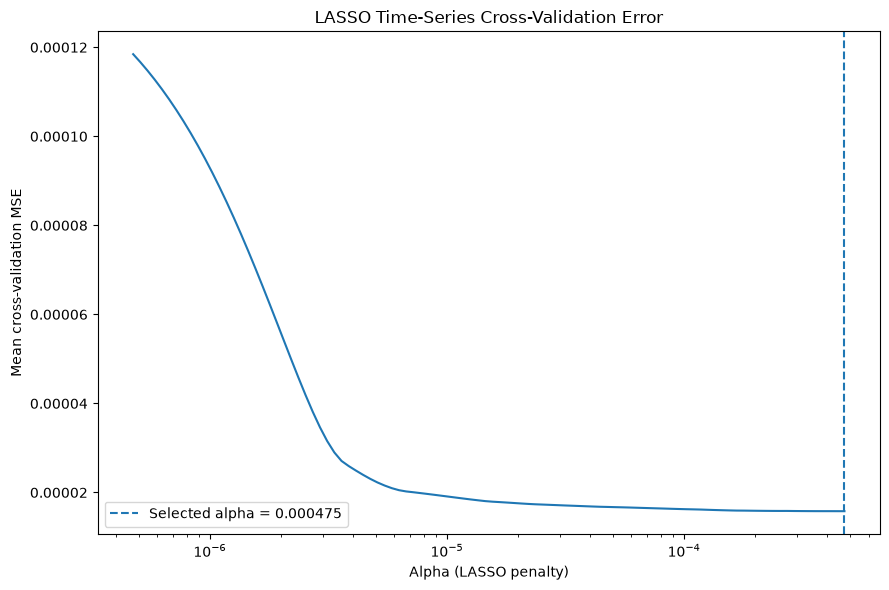

In [74]:
import matplotlib.pyplot as plt

mean_mse = lasso.mse_path_.mean(axis=1)
std_mse = lasso.mse_path_.std(axis=1)

plt.figure(figsize=(9, 6))

plt.semilogx(lasso.alphas_, mean_mse)

plt.axvline(
    lasso.alpha_,
    linestyle="--",
    label=f"Selected alpha = {lasso.alpha_:.6f}"
)

plt.xlabel("Alpha (LASSO penalty)")
plt.ylabel("Mean cross-validation MSE")
plt.title("LASSO Time-Series Cross-Validation Error")
plt.legend()

plt.tight_layout()
plt.show()

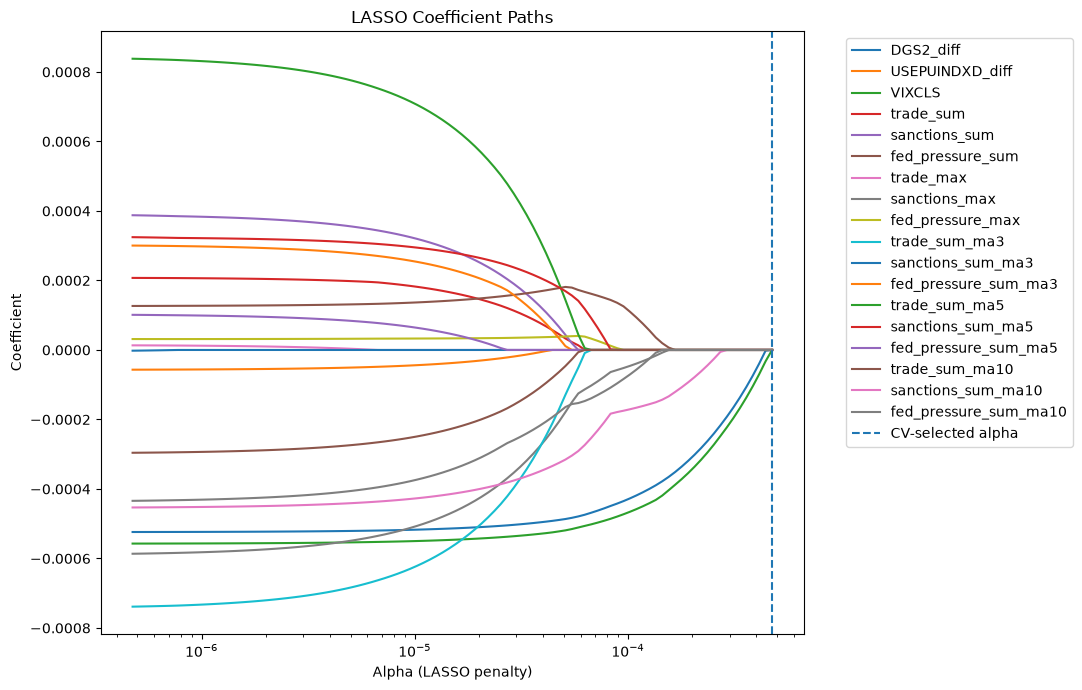

In [75]:
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled,
    y_train,
    alphas=lasso.alphas_
)

plt.figure(figsize=(11, 7))

for i, variable in enumerate(X.columns):
    plt.semilogx(
        alphas_path,
        coefs_path[i],
        label=variable
    )

plt.axvline(
    lasso.alpha_,
    linestyle="--",
    label="CV-selected alpha"
)

plt.xlabel("Alpha (LASSO penalty)")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Paths")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [76]:
summary = pd.DataFrame({
    "Metric": [
        "CV-selected alpha",
        "Predictors tested",
        "Predictors selected at optimal alpha",
        "Test RMSE",
        "Test MAE",
        "Test R²"
    ],
    "Value": [
        lasso.alpha_,
        X.shape[1],
        np.sum(lasso.coef_ != 0),
        rmse,
        mae,
        r2
    ]
})

summary

,Metric,Value
0,CV-selected alpha,0.000475
1,Predictors tested,18.000000
2,Predictors selected at optimal alpha,0.000000
3,Test RMSE,0.004297
4,Test MAE,0.003378
5,Test R²,-0.025421


## 7. Export of LASSO Results

The modelling dataset, cross-validation-selected coefficients, exploratory path variables, summary statistics and diagnostic figures are exported for reproducibility and subsequent comparison with the VAR-X results.

The cross-validation-selected coefficient file records the formal LASSO result, while the exploratory-path file is retained separately to avoid conflating weaker-penalty behaviour with the optimally selected model.

In [77]:
from pathlib import Path

processed_path = Path("../../data/processed")
figures_path = Path("../../data/figures")

# Create figures folder if it does not already exist
figures_path.mkdir(parents=True, exist_ok=True)

print("Processed outputs:", processed_path.resolve())
print("Figures:", figures_path.resolve())

Processed outputs: C:\Users\franc\OneDrive\Geop-Model\data\processed
Figures: C:\Users\franc\OneDrive\Geop-Model\data\figures


In [78]:
lasso_df.to_csv(
    processed_path / "lasso_master_dataset.csv",
    index=False
)

print("Saved lasso_master_dataset.csv")

Saved lasso_master_dataset.csv


In [79]:
lasso_results.to_csv(
    processed_path / "lasso_cv_selected_coefficients.csv",
    index=False
)

print("Saved lasso_cv_selected_coefficients.csv")

Saved lasso_cv_selected_coefficients.csv


In [80]:
selected_6.to_csv(
    processed_path / "lasso_exploratory_path_variables.csv",
    index=False
)

print("Saved lasso_exploratory_path_variables.csv")

Saved lasso_exploratory_path_variables.csv


In [81]:
summary.to_csv(
    processed_path / "lasso_model_summary.csv",
    index=False
)

print("Saved lasso_model_summary.csv")

Saved lasso_model_summary.csv


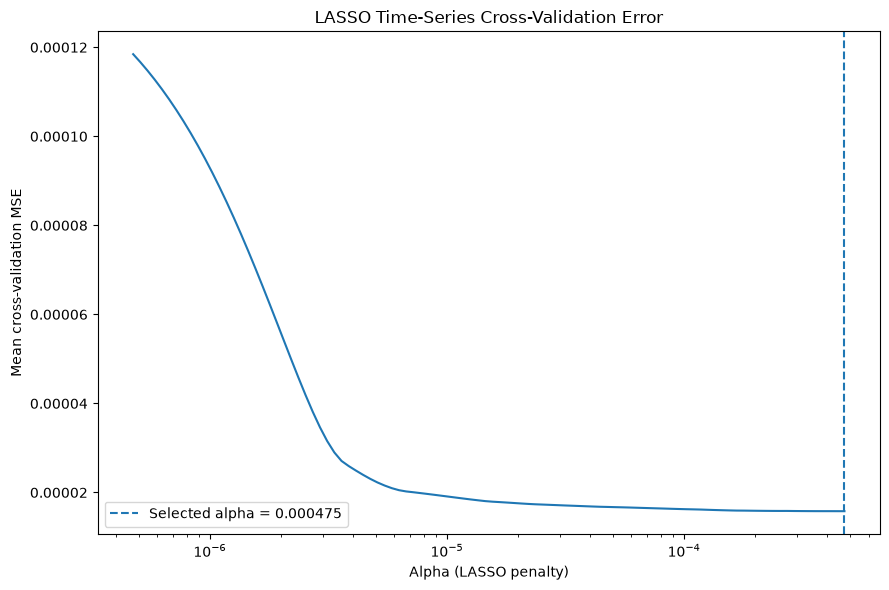

Saved lasso_cv_error.png


In [82]:
plt.figure(figsize=(9, 6))

plt.semilogx(lasso.alphas_, mean_mse)

plt.axvline(
    lasso.alpha_,
    linestyle="--",
    label=f"Selected alpha = {lasso.alpha_:.6f}"
)

plt.xlabel("Alpha (LASSO penalty)")
plt.ylabel("Mean cross-validation MSE")
plt.title("LASSO Time-Series Cross-Validation Error")
plt.legend()

plt.tight_layout()

plt.savefig(
    figures_path / "lasso_cv_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved lasso_cv_error.png")

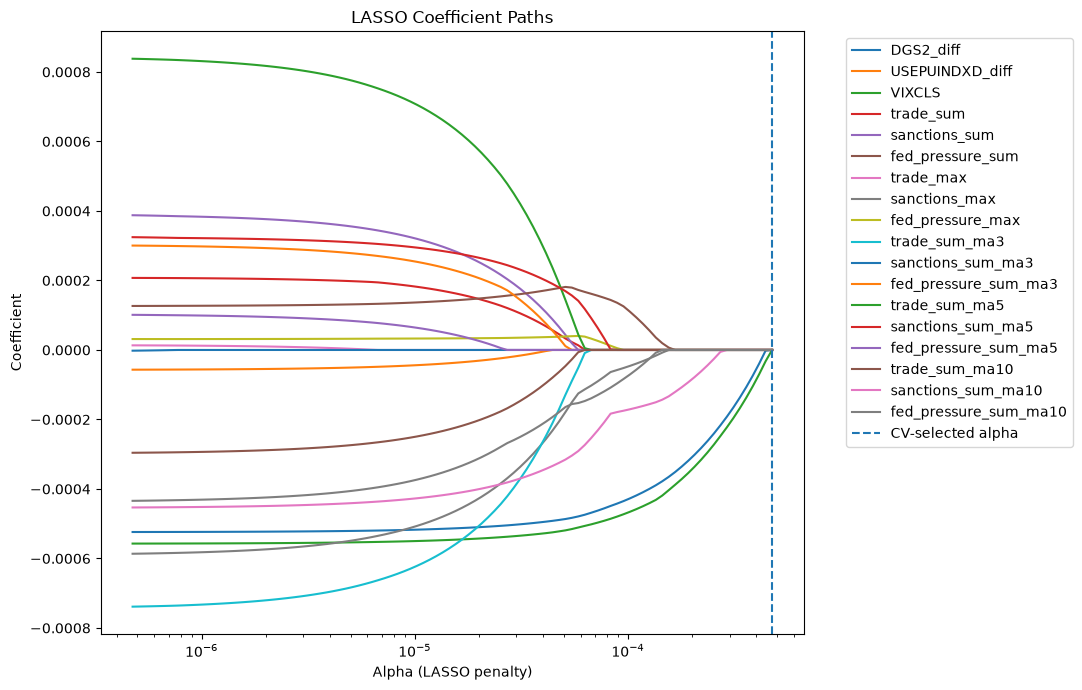

Saved lasso_coefficient_paths.png


In [83]:
plt.figure(figsize=(11, 7))

for i, variable in enumerate(X.columns):
    plt.semilogx(
        alphas_path,
        coefs_path[i],
        label=variable
    )

plt.axvline(
    lasso.alpha_,
    linestyle="--",
    label="CV-selected alpha"
)

plt.xlabel("Alpha (LASSO penalty)")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Paths")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    figures_path / "lasso_coefficient_paths.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved lasso_coefficient_paths.png")

In [84]:
files_to_check = [
    processed_path / "lasso_master_dataset.csv",
    processed_path / "lasso_cv_selected_coefficients.csv",
    processed_path / "lasso_exploratory_path_variables.csv",
    processed_path / "lasso_model_summary.csv",
    figures_path / "lasso_cv_error.png",
    figures_path / "lasso_coefficient_paths.png"
]

for file in files_to_check:
    print(f"{file.name}: {'SAVED' if file.exists() else 'MISSING'}")

lasso_master_dataset.csv: SAVED
lasso_cv_selected_coefficients.csv: SAVED
lasso_exploratory_path_variables.csv: SAVED
lasso_model_summary.csv: SAVED
lasso_cv_error.png: SAVED
lasso_coefficient_paths.png: SAVED


## 8. LASSO Variable-Selection Result

Time-series cross-validation selects the maximum tested penalty (\(\alpha \approx 0.000475\)), at which all 18 candidate predictors are shrunk to zero.

Out-of-sample performance is weak, with RMSE ≈ 0.00430, MAE ≈ 0.00338 and R² ≈ −0.0254.

Inspection of the regularisation path shows that, under weaker penalisation, the earliest surviving predictors include VIX, changes in the US 2-Year Treasury yield, the 10-day moving average of Sanctions Threat, daily summed Federal Reserve Pressure, the 10-day moving average of Federal Reserve Pressure, and daily maximum Sanctions Threat.

These weaker-penalty results are treated as exploratory rather than evidence of robust predictive variable selection.

## Correlation analysis

A Pearson correlation matrix is used to examine contemporaneous linear relationships between EUR/USD log returns and all candidate predictors, as well as correlations among the predictors themselves.

In [85]:
corr_with_eurusd = (
    lasso_df
    .drop(columns="observation_date")
    .corr()["DEXUSEU_logreturn"]
    .drop("DEXUSEU_logreturn")
    .sort_values(key=abs, ascending=False)
)

corr_with_eurusd

DGS2_diff               -0.100754
sanctions_sum_ma10      -0.072031
fed_pressure_sum_ma10   -0.067370
trade_sum_ma10          -0.060214
trade_sum_ma3           -0.045984
VIXCLS                  -0.037632
sanctions_max           -0.034358
sanctions_sum_ma3       -0.028240
fed_pressure_sum         0.027999
fed_pressure_sum_ma5    -0.027659
fed_pressure_max         0.027065
trade_sum_ma5           -0.025545
sanctions_sum_ma5       -0.023320
sanctions_sum           -0.013341
fed_pressure_sum_ma3    -0.010150
USEPUINDXD_diff         -0.007158
trade_sum               -0.006187
trade_max               -0.005488
Name: DEXUSEU_logreturn, dtype: float64

In [86]:
# Correlation matrix for EUR/USD and all candidate predictors

corr_matrix = lasso_df.drop(
    columns=["observation_date"]
).corr()

corr_matrix.round(3)

,DEXUSEU_logreturn,DGS2_diff,USEPUINDXD_diff,VIXCLS,trade_sum,sanctions_sum,fed_pressure_sum,trade_max,sanctions_max,fed_pressure_max,trade_sum_ma3,sanctions_sum_ma3,fed_pressure_sum_ma3,trade_sum_ma5,sanctions_sum_ma5,fed_pressure_sum_ma5,trade_sum_ma10,sanctions_sum_ma10,fed_pressure_sum_ma10
DEXUSEU_logreturn,1.000,-0.101,-0.007,-0.038,-0.006,-0.013,0.028,-0.005,-0.034,0.027,-0.046,-0.028,-0.010,-0.026,-0.023,-0.028,-0.060,-0.072,-0.067
DGS2_diff,-0.101,1.000,0.023,-0.153,-0.062,-0.002,-0.071,-0.067,0.001,-0.082,-0.053,0.028,-0.078,-0.051,0.016,-0.074,-0.018,-0.007,-0.052
USEPUINDXD_diff,-0.007,0.023,1.000,0.032,0.066,0.009,-0.013,0.052,-0.006,-0.007,0.044,0.008,0.014,0.034,0.009,0.012,0.007,-0.003,0.013
VIXCLS,-0.038,-0.153,0.032,1.000,0.036,-0.052,0.028,0.040,-0.047,0.048,0.058,-0.073,0.042,0.054,-0.100,0.063,0.038,-0.134,0.097
trade_sum,-0.006,-0.062,0.066,0.036,1.000,0.270,0.277,0.787,0.254,0.283,0.689,0.173,0.174,0.605,0.147,0.209,0.482,0.119,0.229
sanctions_sum,-0.013,-0.002,0.009,-0.052,0.270,1.000,0.127,0.256,0.861,0.131,0.175,0.688,0.097,0.149,0.551,0.105,0.108,0.402,0.087
fed_pressure_sum,0.028,-0.071,-0.013,0.028,0.277,0.127,1.000,0.208,0.118,0.866,0.238,0.093,0.703,0.229,0.079,0.638,0.255,0.068,0.576
trade_max,-0.005,-0.067,0.052,0.040,0.787,0.256,0.208,1.000,0.260,0.227,0.596,0.191,0.161,0.496,0.172,0.192,0.405,0.148,0.203
sanctions_max,-0.034,0.001,-0.006,-0.047,0.254,0.861,0.118,0.260,1.000,0.108,0.189,0.613,0.124,0.171,0.510,0.131,0.125,0.352,0.097
fed_pressure_max,0.027,-0.082,-0.007,0.048,0.283,0.131,0.866,0.227,0.108,1.000,0.232,0.090,0.630,0.236,0.059,0.590,0.248,0.060,0.558


In [87]:
import seaborn as sns

In [88]:
corr_matrix = (
    lasso_df
    .drop(columns=["observation_date"])
    .corr()
)

print("Correlation matrix shape:", corr_matrix.shape)

corr_matrix.round(3)

Correlation matrix shape: (19, 19)


,DEXUSEU_logreturn,DGS2_diff,USEPUINDXD_diff,VIXCLS,trade_sum,sanctions_sum,fed_pressure_sum,trade_max,sanctions_max,fed_pressure_max,trade_sum_ma3,sanctions_sum_ma3,fed_pressure_sum_ma3,trade_sum_ma5,sanctions_sum_ma5,fed_pressure_sum_ma5,trade_sum_ma10,sanctions_sum_ma10,fed_pressure_sum_ma10
DEXUSEU_logreturn,1.000,-0.101,-0.007,-0.038,-0.006,-0.013,0.028,-0.005,-0.034,0.027,-0.046,-0.028,-0.010,-0.026,-0.023,-0.028,-0.060,-0.072,-0.067
DGS2_diff,-0.101,1.000,0.023,-0.153,-0.062,-0.002,-0.071,-0.067,0.001,-0.082,-0.053,0.028,-0.078,-0.051,0.016,-0.074,-0.018,-0.007,-0.052
USEPUINDXD_diff,-0.007,0.023,1.000,0.032,0.066,0.009,-0.013,0.052,-0.006,-0.007,0.044,0.008,0.014,0.034,0.009,0.012,0.007,-0.003,0.013
VIXCLS,-0.038,-0.153,0.032,1.000,0.036,-0.052,0.028,0.040,-0.047,0.048,0.058,-0.073,0.042,0.054,-0.100,0.063,0.038,-0.134,0.097
trade_sum,-0.006,-0.062,0.066,0.036,1.000,0.270,0.277,0.787,0.254,0.283,0.689,0.173,0.174,0.605,0.147,0.209,0.482,0.119,0.229
sanctions_sum,-0.013,-0.002,0.009,-0.052,0.270,1.000,0.127,0.256,0.861,0.131,0.175,0.688,0.097,0.149,0.551,0.105,0.108,0.402,0.087
fed_pressure_sum,0.028,-0.071,-0.013,0.028,0.277,0.127,1.000,0.208,0.118,0.866,0.238,0.093,0.703,0.229,0.079,0.638,0.255,0.068,0.576
trade_max,-0.005,-0.067,0.052,0.040,0.787,0.256,0.208,1.000,0.260,0.227,0.596,0.191,0.161,0.496,0.172,0.192,0.405,0.148,0.203
sanctions_max,-0.034,0.001,-0.006,-0.047,0.254,0.861,0.118,0.260,1.000,0.108,0.189,0.613,0.124,0.171,0.510,0.131,0.125,0.352,0.097
fed_pressure_max,0.027,-0.082,-0.007,0.048,0.283,0.131,0.866,0.227,0.108,1.000,0.232,0.090,0.630,0.236,0.059,0.590,0.248,0.060,0.558


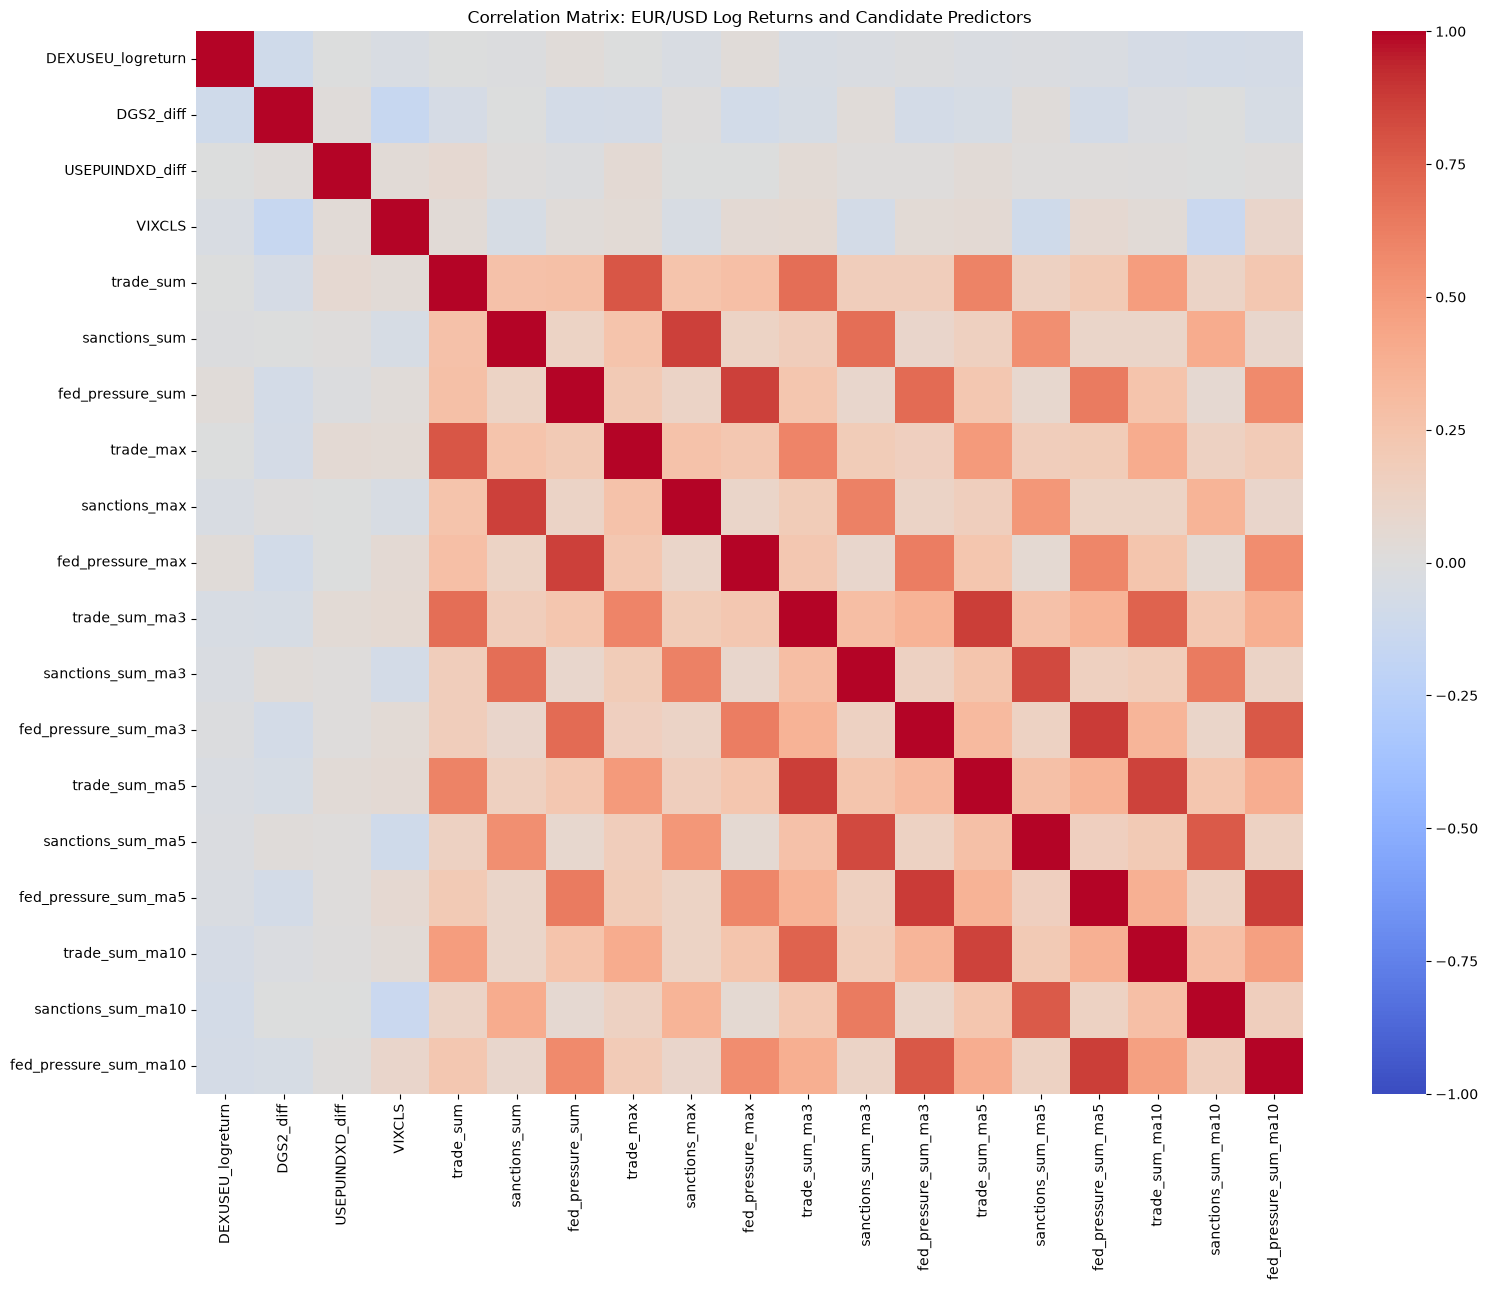

In [89]:
plt.figure(figsize=(16, 13))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title(
    "Correlation Matrix: EUR/USD Log Returns and Candidate Predictors"
)

plt.tight_layout()

plt.savefig(
    "lasso_logreturn_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
corr_matrix.to_csv("lasso_logreturn_correlation_matrix.csv")

print("Correlation matrix saved.")

Correlation matrix saved.


## Granger causality analysis

Granger causality tests are used to assess whether lagged values of each candidate predictor contain statistically significant information for predicting EUR/USD log returns beyond the information contained in past EUR/USD log returns.

Tests are conducted at lags 1, 2, and 3, consistent with the short lag structures considered in the VARX analysis. A p-value below 0.05 is treated as evidence of Granger predictive significance at that lag.

In [91]:
from statsmodels.tsa.stattools import grangercausalitytests

In [93]:
# Run Granger causality tests for each candidate predictor

max_lag = 3
granger_results = []

predictors = [
    col for col in lasso_df.columns
    if col not in ["observation_date", "DEXUSEU_logreturn"]
]

for predictor in predictors:

    # Statsmodels tests whether the second column Granger-causes the first
    test_data = (
        lasso_df[
            ["DEXUSEU_logreturn", predictor]
        ]
        .dropna()
    )

    results = grangercausalitytests(
        test_data,
        maxlag=max_lag,
        verbose=False
    )

    granger_results.append({
        "Predictor": predictor,
        "Lag_1_pvalue": results[1][0]["ssr_ftest"][1],
        "Lag_2_pvalue": results[2][0]["ssr_ftest"][1],
        "Lag_3_pvalue": results[3][0]["ssr_ftest"][1]
    })

granger_df = pd.DataFrame(granger_results)

print("Number of predictors tested:", len(granger_df))

granger_df

c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print 

Number of predictors tested: 18


,Predictor,Lag_1_pvalue,Lag_2_pvalue,Lag_3_pvalue
0,DGS2_diff,0.011704,0.019079,0.029342
1,USEPUINDXD_diff,0.910593,0.966610,0.920879
2,VIXCLS,0.244526,0.001676,0.002575
3,trade_sum,0.983515,0.722200,0.628487
4,sanctions_sum,0.754117,0.942823,0.407303
5,fed_pressure_sum,0.524323,0.605673,0.352755
6,trade_max,0.294443,0.328778,0.517003
7,sanctions_max,0.959970,0.771994,0.235123
8,fed_pressure_max,0.658539,0.655728,0.388867
9,trade_sum_ma3,0.243119,0.402295,0.500053


In [94]:
granger_display = granger_df.copy()

granger_display[
    ["Lag_1_pvalue", "Lag_2_pvalue", "Lag_3_pvalue"]
] = granger_display[
    ["Lag_1_pvalue", "Lag_2_pvalue", "Lag_3_pvalue"]
].round(4)

granger_display

,Predictor,Lag_1_pvalue,Lag_2_pvalue,Lag_3_pvalue
0,DGS2_diff,0.0117,0.0191,0.0293
1,USEPUINDXD_diff,0.9106,0.9666,0.9209
2,VIXCLS,0.2445,0.0017,0.0026
3,trade_sum,0.9835,0.7222,0.6285
4,sanctions_sum,0.7541,0.9428,0.4073
5,fed_pressure_sum,0.5243,0.6057,0.3528
6,trade_max,0.2944,0.3288,0.5170
7,sanctions_max,0.9600,0.7720,0.2351
8,fed_pressure_max,0.6585,0.6557,0.3889
9,trade_sum_ma3,0.2431,0.4023,0.5001


### Granger causality results

Using a 5% significance threshold, the unadjusted Granger causality tests identify several predictors with lagged predictive information for EUR/USD log returns.

- **DGS2_diff** is significant at all three lag specifications (lag 1: p = 0.0117; lag 2: p = 0.0191; lag 3: p = 0.0293), providing consistent evidence of lagged predictive information from changes in the US 2-year Treasury yield.
- **VIXCLS** is significant when up to two and three lags are included (p = 0.0017 and p = 0.0026 respectively), although it is not significant at lag 1.
- Among the geopolitical variables, the strongest evidence is concentrated in the **10-day moving-average measures**. Trade MA10 (p = 0.0283), sanctions MA10 (p = 0.0189), and Fed-pressure MA10 (p = 0.0214) are significant at lag 1. Fed-pressure MA10 also remains significant at lag 2 (p = 0.0440).
- The raw SUM, MAX, MA3 and MA5 geopolitical specifications do not reach the 5% significance threshold at the tested lag specifications.

These results suggest that lagged relationships may be more informative than contemporaneous relationships for EUR/USD movements. In particular, the concentration of geopolitical significance in the MA10 variables suggests that geopolitical information aggregated over a longer window may contain more predictive information than daily or shorter-window measures.

Granger causality should be interpreted as evidence of temporal predictive content rather than structural or economic causation. Furthermore, because multiple predictor-lag combinations are tested, these unadjusted results are treated as preliminary and are subsequently assessed using a multiple-testing correction.

### Multiple-testing robustness check

The Granger causality analysis tests 18 candidate predictors across three lag specifications, resulting in 54 hypothesis tests. Conducting many simultaneous tests increases the probability of obtaining statistically significant results by chance.

To assess the robustness of the unadjusted Granger results, the Benjamini–Hochberg (BH) procedure is applied to control the false discovery rate (FDR) at 5%. This correction adjusts the p-values to account for multiple testing while being less conservative than a Bonferroni correction.

Predictive relationships that remain significant after the BH correction provide stronger evidence of Granger-predictive information for EUR/USD log returns. Results that are significant only before correction are treated as exploratory evidence.

In [95]:
from statsmodels.stats.multitest import multipletests

pvalue_columns = [
    "Lag_1_pvalue",
    "Lag_2_pvalue",
    "Lag_3_pvalue"
]

all_pvalues = granger_df[pvalue_columns].to_numpy().flatten()

reject, pvals_corrected, _, _ = multipletests(
    all_pvalues,
    alpha=0.05,
    method="fdr_bh"
)

print("Total tests:", len(all_pvalues))
print("Significant before correction:", np.sum(all_pvalues < 0.05))
print("Significant after BH correction:", np.sum(reject))

Total tests: 54
Significant before correction: 9
Significant after BH correction: 0


In [97]:
granger_corrected = granger_df.copy()

granger_corrected[
    ["Lag_1_BH", "Lag_2_BH", "Lag_3_BH"]
] = pvals_corrected.reshape(18, 3)

granger_corrected["Lag_1_significant"] = (
    granger_corrected["Lag_1_BH"] < 0.05
)

granger_corrected["Lag_2_significant"] = (
    granger_corrected["Lag_2_BH"] < 0.05
)

granger_corrected["Lag_3_significant"] = (
    granger_corrected["Lag_3_BH"] < 0.05
)

granger_corrected[[
    "Predictor",
    "Lag_1_pvalue", "Lag_1_BH", "Lag_1_significant",
    "Lag_2_pvalue", "Lag_2_BH", "Lag_2_significant",
    "Lag_3_pvalue", "Lag_3_BH", "Lag_3_significant"
]].round(4)

,Predictor,Lag_1_pvalue,Lag_1_BH,Lag_1_significant,Lag_2_pvalue,Lag_2_BH,Lag_2_significant,Lag_3_pvalue,Lag_3_BH,Lag_3_significant
0,DGS2_diff,0.0117,0.1922,False,0.0191,0.1922,False,0.0293,0.1981,False
1,USEPUINDXD_diff,0.9106,0.9835,False,0.9666,0.9835,False,0.9209,0.9835,False
2,VIXCLS,0.2445,0.5079,False,0.0017,0.0695,False,0.0026,0.0695,False
3,trade_sum,0.9835,0.9835,False,0.7222,0.8478,False,0.6285,0.7893,False
4,sanctions_sum,0.7541,0.8664,False,0.9428,0.9835,False,0.4073,0.6110,False
5,fed_pressure_sum,0.5243,0.6906,False,0.6057,0.7787,False,0.3528,0.5953,False
6,trade_max,0.2944,0.5483,False,0.3288,0.5727,False,0.5170,0.6906,False
7,sanctions_max,0.9600,0.9835,False,0.7720,0.8685,False,0.2351,0.5079,False
8,fed_pressure_max,0.6585,0.7902,False,0.6557,0.7902,False,0.3889,0.6110,False
9,trade_sum_ma3,0.2431,0.5079,False,0.4023,0.6110,False,0.5001,0.6906,False


### Multiple-testing correction results

Nine of the 54 Granger causality tests were statistically significant at the unadjusted 5% level. However, none remained significant at the 5% level after applying the Benjamini–Hochberg false-discovery-rate correction.

The strongest adjusted evidence was observed for VIXCLS when up to two and three lags were included. The corresponding raw p-values of 0.0017 and 0.0026 increased to BH-adjusted p-values of approximately 0.0695. Although these results no longer meet the pre-specified 5% significance threshold, they remain the strongest evidence of lagged predictive information among the variables examined.

The previously significant geopolitical MA10 results also did not survive the multiple-testing correction. Their adjusted p-values were substantially above 0.05. Consequently, the unadjusted Granger results for the geopolitical indices are interpreted as exploratory rather than robust evidence of predictive significance.

Overall, the correction provides no statistically robust evidence, at a 5% false-discovery-rate threshold, that any individual candidate predictor Granger-predicts EUR/USD log returns across the set of tests considered.

In [98]:
granger_df.to_csv(
    "granger_causality_raw_pvalues.csv",
    index=False
)

granger_corrected.to_csv(
    "granger_causality_BH_corrected.csv",
    index=False
)

print("Granger causality results saved.")

Granger causality results saved.


## 9. Overall Summary

The LASSO analysis provides little evidence of robust linear predictive power for EUR/USD log returns from the candidate macroeconomic and geopolitical variables.

Time-series cross-validation selects the strongest penalty tested and shrinks all 18 predictor coefficients to zero. Out-of-sample performance is weak and produces a negative R², indicating that the optimally regularised model does not improve meaningfully on a simple benchmark.

Contemporaneous correlations between EUR/USD log returns and the candidate predictors are also generally small. Unadjusted Granger causality tests identify several apparent lagged relationships, including some involving the 10-day moving-average geopolitical indices. However, none of the 54 tests remains statistically significant after controlling the false discovery rate using the Benjamini–Hochberg procedure.

Taken together, these results provide no robust evidence that any individual geopolitical representation independently predicts EUR/USD log returns within the linear variable-selection and Granger-causality frameworks considered. The weaker-penalty LASSO paths and unadjusted Granger results are therefore treated as exploratory evidence rather than confirmed predictive relationships.